# Sentiment Analysis with LSTM — Giai đoạn 4: Extensions (GRU, Bidirectional LSTM, GloVe)

**Yêu cầu:** đã có `vocab.pkl`, `imdb_processed.pt` trong `MyDrive/imdb_sentiment_artifacts/` (Giai đoạn 1) và lý tưởng là `baseline_results.json` (Giai đoạn 2) để so sánh cuối notebook.

**Nội dung notebook:** train tuần tự 3 biến thể, mỗi biến thể dùng lại cùng data pipeline + training loop + evaluation như baseline để so sánh công bằng:
1. Mount Drive, load artifact & tạo lại DataLoader (giống Giai đoạn 2)
2. Hàm train/eval dùng chung cho cả 3 model
3. **Model A — GRU**: thay LSTM bằng GRU
4. **Model B — Bidirectional LSTM**: LSTM 2 chiều
5. **Model C — GloVe embeddings**: tải pre-trained GloVe, khởi tạo Embedding layer từ đó (kết hợp với LSTM 1 chiều như baseline để cô lập tác động của GloVe)
6. Tổng hợp & lưu kết quả 3 model vào `extension_results.json`


## 1. Mount Drive, load artifact & tạo lại DataLoader

In [1]:
from google.colab import drive
drive.mount('/content/drive')
ARTIFACT_DIR = "/content/drive/MyDrive/imdb_sentiment_artifacts"

import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import time
import json
from torch.utils.data import TensorDataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(f"{ARTIFACT_DIR}/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

data = torch.load(f"{ARTIFACT_DIR}/imdb_processed.pt")
X_train_full, y_train_full = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
MAX_LEN = data["max_len"]
VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE, "| Max len:", MAX_LEN)

full_dataset = TensorDataset(X_train_full, y_train_full)
val_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Mounted at /content/drive
Using device: cuda
Vocab size: 20000 | Max len: 250
Train: 22500 | Val: 2500 | Test: 25000


## 2. Hàm train/eval dùng chung cho cả 3 model

Tách riêng logic training + evaluation để đảm bảo mọi biến thể được huấn luyện/đánh giá công bằng như nhau (cùng số epoch, optimizer, batch size).

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_accuracy(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).float()
    return (preds == labels).float().mean().item()

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item()
            total_acc += compute_accuracy(logits, yb)
            n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

def train_model(model, model_name, num_epochs=15, lr=1e-3, patience=3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_val_loss = float("inf")
    epochs_no_improve = 0
    ckpt_path = f"{ARTIFACT_DIR}/{model_name}_best.pt"

    start_total = time.time()
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt_path)

        print(f"[{model_name}] Epoch {epoch}/{num_epochs} ({elapsed:.1f}s) | "
              f"Train loss: {tr_loss:.4f}, acc: {tr_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

        # Early stopping dựa trên val loss
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{model_name}] Early stopping tại epoch {epoch} (val loss không cải thiện sau {patience} epoch liên tiếp).")
                break

    total_time = time.time() - start_total
    model.load_state_dict(torch.load(ckpt_path))
    return model, history, best_val_acc, total_time

def evaluate_model(model, model_name, num_params, history, train_time):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"\n=== {model_name} — Test results ===")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"Params: {num_params:,} | Train time: {train_time:.1f}s")

    return {
        "model_name": model_name,
        "num_params": num_params,
        "train_time_sec": train_time,
        "test_accuracy": acc,
        "test_precision": prec,
        "test_recall": rec,
        "test_f1": f1,
        "history": history,
    }

NUM_EPOCHS = 15  # early stopping (patience=3) sẽ tự dừng sớm nếu hội tụ trước
all_results = {}


## 3. Model A — GRU

Thay `nn.LSTM` bằng `nn.GRU` (ít cổng hơn LSTM → thường train nhanh hơn), giữ nguyên phần còn lại của kiến trúc.

In [3]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)          # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)
        out = self.dropout(hidden)
        return self.fc(out).squeeze(1)

gru_model = GRUSentimentModel(vocab_size=VOCAB_SIZE).to(device)
gru_num_params = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"GRU model — số tham số: {gru_num_params:,}")

gru_model, gru_history, gru_best_val, gru_train_time = train_model(gru_model, "gru", num_epochs=NUM_EPOCHS)
all_results["GRU"] = evaluate_model(gru_model, "GRU", gru_num_params, gru_history, gru_train_time)

GRU model — số tham số: 2,659,201
[gru] Epoch 1/15 (7.7s) | Train loss: 0.6195, acc: 0.6427 | Val loss: 0.5564, acc: 0.7203
[gru] Epoch 2/15 (5.2s) | Train loss: 0.4442, acc: 0.8008 | Val loss: 0.4444, acc: 0.8145
[gru] Epoch 3/15 (5.7s) | Train loss: 0.3122, acc: 0.8735 | Val loss: 0.3768, acc: 0.8367
[gru] Epoch 4/15 (5.9s) | Train loss: 0.2195, acc: 0.9164 | Val loss: 0.3553, acc: 0.8680
[gru] Epoch 5/15 (5.2s) | Train loss: 0.1504, acc: 0.9461 | Val loss: 0.3610, acc: 0.8723
[gru] Epoch 6/15 (6.4s) | Train loss: 0.0996, acc: 0.9683 | Val loss: 0.3981, acc: 0.8680
[gru] Epoch 7/15 (5.3s) | Train loss: 0.0634, acc: 0.9803 | Val loss: 0.4503, acc: 0.8586
[gru] Early stopping tại epoch 7 (val loss không cải thiện sau 3 epoch liên tiếp).

=== GRU — Test results ===
Accuracy : 0.8643 | Precision: 0.8584 | Recall: 0.8726 | F1: 0.8654
Params: 2,659,201 | Train time: 41.5s


## 4. Model B — Bidirectional LSTM

LSTM đọc câu theo cả 2 chiều; hidden state cuối cùng gộp (concat) chiều thuận + chiều nghịch, nên Dense layer nhận `hidden_dim * 2`.

In [4]:
class BiLSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)   # x2 vì bidirectional
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)     # hidden: (2, batch, hidden_dim)
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1)  # (batch, hidden_dim*2)
        out = self.dropout(hidden_cat)
        return self.fc(out).squeeze(1)

bilstm_model = BiLSTMSentimentModel(vocab_size=VOCAB_SIZE).to(device)
bilstm_num_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"BiLSTM model — số tham số: {bilstm_num_params:,}")

bilstm_model, bilstm_history, bilstm_best_val, bilstm_train_time = train_model(bilstm_model, "bilstm", num_epochs=NUM_EPOCHS)
all_results["BiLSTM"] = evaluate_model(bilstm_model, "BiLSTM", bilstm_num_params, bilstm_history, bilstm_train_time)

BiLSTM model — số tham số: 2,824,449
[bilstm] Epoch 1/15 (9.4s) | Train loss: 0.6339, acc: 0.6335 | Val loss: 0.5478, acc: 0.7121
[bilstm] Epoch 2/15 (8.8s) | Train loss: 0.4750, acc: 0.7717 | Val loss: 0.4619, acc: 0.7852
[bilstm] Epoch 3/15 (9.1s) | Train loss: 0.3765, acc: 0.8331 | Val loss: 0.4093, acc: 0.8133
[bilstm] Epoch 4/15 (11.8s) | Train loss: 0.2951, acc: 0.8762 | Val loss: 0.3873, acc: 0.8363
[bilstm] Epoch 5/15 (9.4s) | Train loss: 0.2296, acc: 0.9103 | Val loss: 0.4206, acc: 0.8316
[bilstm] Epoch 6/15 (8.4s) | Train loss: 0.1865, acc: 0.9277 | Val loss: 0.4153, acc: 0.8445
[bilstm] Epoch 7/15 (9.6s) | Train loss: 0.1251, acc: 0.9526 | Val loss: 0.4454, acc: 0.8453
[bilstm] Early stopping tại epoch 7 (val loss không cải thiện sau 3 epoch liên tiếp).

=== BiLSTM — Test results ===
Accuracy : 0.8350 | Precision: 0.8449 | Recall: 0.8206 | F1: 0.8326
Params: 2,824,449 | Train time: 66.8s


## 5. Model C — GloVe embeddings

Dùng LSTM 1 chiều giống baseline (để cô lập tác động riêng của GloVe), chỉ thay Embedding layer bằng trọng số pre-trained thay vì học từ đầu.

Tải `glove.6B.100d.txt` (~822MB zip, chứa nhiều chiều — ta chỉ dùng bản 100d để nhẹ và khớp `embedding_dim`).

In [5]:
import os

GLOVE_DIR = f"{ARTIFACT_DIR}/glove"
os.makedirs(GLOVE_DIR, exist_ok=True)
GLOVE_FILE = f"{GLOVE_DIR}/glove.6B.100d.txt"

if not os.path.exists(GLOVE_FILE):
    print("Đang tải GloVe (lần đầu, ~822MB zip, có thể mất vài phút)...")
    !wget -q -nc http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -q -o /content/glove.6B.zip glove.6B.100d.txt -d {GLOVE_DIR}
    print("Đã tải và giải nén xong, lưu vào Drive để lần sau không cần tải lại.")
else:
    print("Đã có sẵn glove.6B.100d.txt trong Drive, bỏ qua tải lại.")


Đang tải GloVe (lần đầu, ~822MB zip, có thể mất vài phút)...
Đã tải và giải nén xong, lưu vào Drive để lần sau không cần tải lại.


In [6]:
import numpy as np

EMBEDDING_DIM = 100  # phải khớp với GloVe 100d

print("Đang load GloVe vectors vào bộ nhớ...")
glove_dict = {}
with open(GLOVE_FILE, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype="float32")
        glove_dict[word] = vec
print(f"Đã load {len(glove_dict):,} word vectors từ GloVe.")

# Xây embedding matrix khớp với vocab hiện có
embedding_matrix = np.random.normal(scale=0.1, size=(VOCAB_SIZE, EMBEDDING_DIM)).astype("float32")
embedding_matrix[vocab["<pad>"]] = np.zeros(EMBEDDING_DIM, dtype="float32")

found = 0
for word, idx in vocab.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
        found += 1

print(f"Số từ trong vocab tìm thấy trong GloVe: {found}/{VOCAB_SIZE} ({found/VOCAB_SIZE*100:.1f}%)")
embedding_matrix = torch.tensor(embedding_matrix)


Đang load GloVe vectors vào bộ nhớ...
Đã load 400,000 word vectors từ GloVe.
Số từ trong vocab tìm thấy trong GloVe: 19154/20000 (95.8%)


In [7]:
class GloVeLSTMSentimentModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, pad_idx=0, dropout=0.3, freeze_embedding=False):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embedding, padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        hidden = hidden.squeeze(0)
        out = self.dropout(hidden)
        return self.fc(out).squeeze(1)

# freeze_embedding=False -> fine-tune GloVe cùng lúc train (thường cho kết quả tốt hơn freeze hoàn toàn)
glove_model = GloVeLSTMSentimentModel(embedding_matrix, freeze_embedding=False).to(device)
glove_num_params = sum(p.numel() for p in glove_model.parameters() if p.requires_grad)
print(f"GloVe+LSTM model — số tham số: {glove_num_params:,}")

glove_model, glove_history, glove_best_val, glove_train_time = train_model(glove_model, "glove_lstm", num_epochs=NUM_EPOCHS)
all_results["GloVe+LSTM"] = evaluate_model(glove_model, "GloVe+LSTM", glove_num_params, glove_history, glove_train_time)

GloVe+LSTM model — số tham số: 2,117,889
[glove_lstm] Epoch 1/15 (6.5s) | Train loss: 0.6334, acc: 0.6424 | Val loss: 0.5365, acc: 0.7457
[glove_lstm] Epoch 2/15 (5.2s) | Train loss: 0.4412, acc: 0.8071 | Val loss: 0.4013, acc: 0.8484
[glove_lstm] Epoch 3/15 (6.2s) | Train loss: 0.2794, acc: 0.8890 | Val loss: 0.3117, acc: 0.8621
[glove_lstm] Epoch 4/15 (5.3s) | Train loss: 0.1900, acc: 0.9333 | Val loss: 0.3102, acc: 0.8805
[glove_lstm] Epoch 5/15 (5.4s) | Train loss: 0.1258, acc: 0.9585 | Val loss: 0.3415, acc: 0.8836
[glove_lstm] Epoch 6/15 (6.1s) | Train loss: 0.0756, acc: 0.9776 | Val loss: 0.3793, acc: 0.8691
[glove_lstm] Epoch 7/15 (5.3s) | Train loss: 0.0477, acc: 0.9870 | Val loss: 0.4542, acc: 0.8789
[glove_lstm] Early stopping tại epoch 7 (val loss không cải thiện sau 3 epoch liên tiếp).

=== GloVe+LSTM — Test results ===
Accuracy : 0.8553 | Precision: 0.8820 | Recall: 0.8204 | F1: 0.8501
Params: 2,117,889 | Train time: 40.2s


## 6. Tổng hợp & lưu kết quả 3 model

In [8]:
import pandas as pd

summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        "Model": name,
        "Params": res["num_params"],
        "Train time (s)": round(res["train_time_sec"], 1),
        "Test Accuracy": round(res["test_accuracy"], 4),
        "Precision": round(res["test_precision"], 4),
        "Recall": round(res["test_recall"], 4),
        "F1": round(res["test_f1"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

with open(f"{ARTIFACT_DIR}/extension_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nĐã lưu extension_results.json vào {ARTIFACT_DIR}/")


     Model  Params  Train time (s)  Test Accuracy  Precision  Recall     F1
       GRU 2659201            41.5         0.8643     0.8584  0.8726 0.8654
    BiLSTM 2824449            66.8         0.8350     0.8449  0.8206 0.8326
GloVe+LSTM 2117889            40.2         0.8553     0.8820  0.8204 0.8501

Đã lưu extension_results.json vào /content/drive/MyDrive/imdb_sentiment_artifacts/


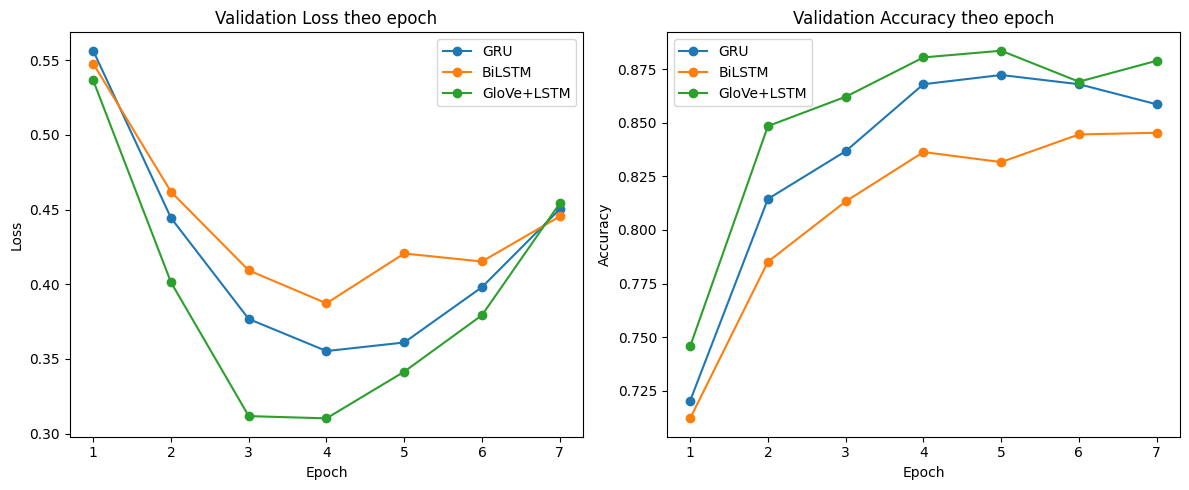

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, res in all_results.items():
    epochs_range = range(1, len(res["history"]["val_loss"]) + 1)  # độ dài thật, khác nhau giữa các model do early stopping
    axes[0].plot(epochs_range, res["history"]["val_loss"], marker="o", label=name)
    axes[1].plot(epochs_range, res["history"]["val_acc"], marker="o", label=name)

axes[0].set_title("Validation Loss theo epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy theo epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


---
### ✅ Kết thúc Giai đoạn 4

Đã có:
- 3 model mở rộng huấn luyện & đánh giá xong: **GRU**, **Bidirectional LSTM**, **GloVe+LSTM**
- `extension_results.json` + checkpoint từng model lưu trong Drive
- Bảng so sánh nhanh (params, thời gian train, accuracy/F1) và biểu đồ so sánh validation loss/accuracy giữa 3 biến thể

**Bước tiếp theo (Giai đoạn 5):** ghép `baseline_results.json` (Giai đoạn 2) + `extension_results.json` (notebook này) thành 1 bảng so sánh tổng, viết nhận xét — đây sẽ là input chính cho slide/README tổng kết cuối cùng.
